# Visualizing results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
score_dir = "/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/scores"
score_files = {
    corpus: f"{score_dir}/scores_{corpus}.csv" for corpus in ["rocsmt", "footweets", "mmtc", "pfsmb", "rocsmt-gpt", "footweets-gpt", "mmtc-gpt", "pfsmb-gpt"]
}

In [201]:
dfs = {corpus: pd.read_csv(score_files[corpus]) for corpus in score_files}

In [58]:
from llm.prompt_templates import GUIDELINE_NAMES, LLAMA_MODEL_NAME, GEMMA_MODEL_NAME

In [60]:
NLLB_MODEL_NAME = "nllb-200-3.3B"

In [5]:
GUIDELINE_NAMES

['default', 'standard', 'general']

In [34]:
GUIDELINES = {
    "default": 0,
    "standard": 1,
    "general": 2,
}

In [176]:
MODELS = {
    NLLB_MODEL_NAME:{
        "name": "NLLB-3B",
        "id": "0",
    },
    LLAMA_MODEL_NAME:{
        "name": "LLaMa-3.1-8B",
        "id": "1",
    },
    GEMMA_MODEL_NAME:{
        "name": "Gemma-2-9B",
        "id": "2",
    }
}

In [205]:
CORPORA = {
    "rocsmt": {
        "name": "RoCS-MT",
        "id": "0",
        "refs": "raw"
    },
    "rocsmt-gpt": {
        "name": "RoCS-MT",
        "id": "1",
        "refs": "norm"
    },
    "footweets": {
        "name": "FooTweets",
        "id": "2",
        "refs": "raw"
    },
    "footweets-gpt": {
        "name": "FooTweets",
        "id": "3",
        "refs": "norm"
    },
    "mmtc": {
        "name": "MMTC",
        "id": "4",
        "refs": "raw"
    },
    "mmtc-gpt": {
        "name": "MMTC",
        "id": "5",
        "refs": "norm"
    },
    "pfsmb": {
        "name": "PFSMB",
        "id": "6",
        "refs": "raw"
    },
    "pfsmb-gpt": {
        "name": "PFSMB",
        "id": "7",
        "refs": "norm"
    }
}

In [206]:
def get_guidelines(filename):
    guideline = filename.split(".")[-2]
    if guideline not in GUIDELINE_NAMES:
        guideline = "default"
    return guideline

def get_model_names(model):
    return MODELS[model.split("/")[-1]]["name"]

def get_model_id(model):
    return MODELS[model.split("/")[-1]]["id"]

def get_guideline_id(guideline):
    return GUIDELINES[guideline]

def get_corpus_id(corpus):
    return CORPORA[corpus]["id"]

def get_corpus_name(corpus):
    return CORPORA[corpus]["name"]

def get_reference_type(corpus):
    return CORPORA[corpus]["refs"]

In [229]:
def normalize_error_counts(data):
    data["minor"] = data["minor"] / data["total"] * 100
    data["major"] = data["major"] / data["total"] * 100
    data["critical"] = data["critical"] / data["total"] * 100
    return data

In [236]:
all_data = pd.DataFrame()

for corpus in dfs:
    data = dfs[corpus].copy()
    data["guideline"] = data["file"].apply(get_guidelines)
    data["model_name"] = data["model"].apply(get_model_names)+ " (" + data["guideline"]  + ")"
    data["model_id"] = data["model"].apply(get_model_id)
    data["guideline_id"] = data["guideline"].apply(get_guideline_id)
    data["corpus"] = get_corpus_name(corpus)
    data["corpus_id"] = get_corpus_id(corpus)
    data["reference_type"] = get_reference_type(corpus)
    all_data = all_data.append(data)



/home/lnishimw/scratch/tmp/ipykernel_3393968/2278828391.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/2278828391.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/2278828391.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/2278828391.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_data = all_data.append(data)
/home/lnishimw/scratch/tmp/ipykernel_3393968/2278828391.py:12: FutureWarning

In [237]:
all_data = all_data.sort_values(["corpus_id", "model_id", "guideline_id", "reference_type"], ascending=[True, True, True, False])
all_data.head()

,model,file,bleu,chrf2,comet,xcomet,minor,major,critical,total,guideline,model_name,model_id,guideline_id,corpus,corpus_id,reference_type
0,facebook/nllb-200-3.3B,raw.en.test.out,21.332086,43.825091,73.213880,77.169062,1230,2352,105,3687,default,NLLB-3B (default),0,0,RoCS-MT,0,raw
1,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.default.out,20.161005,42.723988,74.026405,78.217072,1380,2499,76,3955,default,LLaMa-3.1-8B (default),1,0,RoCS-MT,0,raw
2,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.standard.out,20.044900,42.703130,74.139383,78.247300,1364,2498,90,3952,standard,LLaMa-3.1-8B (standard),1,1,RoCS-MT,0,raw
3,meta-llama/Llama-3.1-8B-Instruct,raw.en.test.general.out,19.975092,42.499427,74.459183,78.732861,1398,2495,80,3973,general,LLaMa-3.1-8B (general),1,2,RoCS-MT,0,raw
4,google/gemma-2-9b-it,raw.en.test.default.out,23.571598,46.148452,76.827113,81.626830,1570,2198,62,3830,default,Gemma-2-9B (default),2,0,RoCS-MT,0,raw


In [ ]:

sns.barplot(x="chrf2", y="model_name", hue="reference_type", data=all_data[all_data["corpus"] == "MMTC"])
# put the legenf outside the plot
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=2)
plt.show()



In [292]:
def plot_scores(all_data, metrics, sharex=True, sharey=True):
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(metrics), figsize=(4*len(metrics), 3*len(corpora)), sharex=sharex, sharey=sharey)
    for i, corpus in enumerate(corpora):
        for j, metric in enumerate(metrics):
            data = all_data[all_data["corpus"] == corpus]
            sns.barplot(x=metric, y="model_name", hue="reference_type", ax=axs[i,j], data=data) #, vmin=0, vmax=100) , cmap="YlGnBu"
            axs[i,j].set_title(f"{corpus}")
            axs[i,j].set_ylabel("Model")
    plt.tight_layout()
    plt.show()


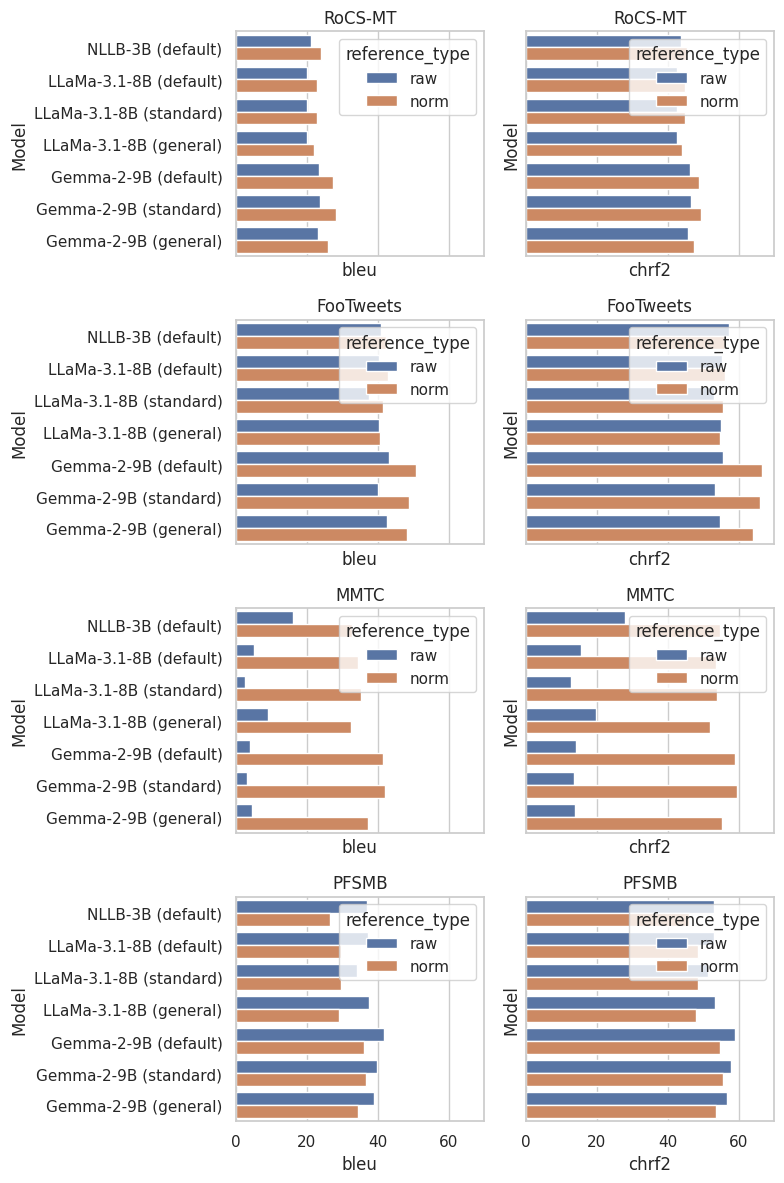

In [293]:
metrics = ["bleu", "chrf2"]
plot_scores(all_data, metrics)

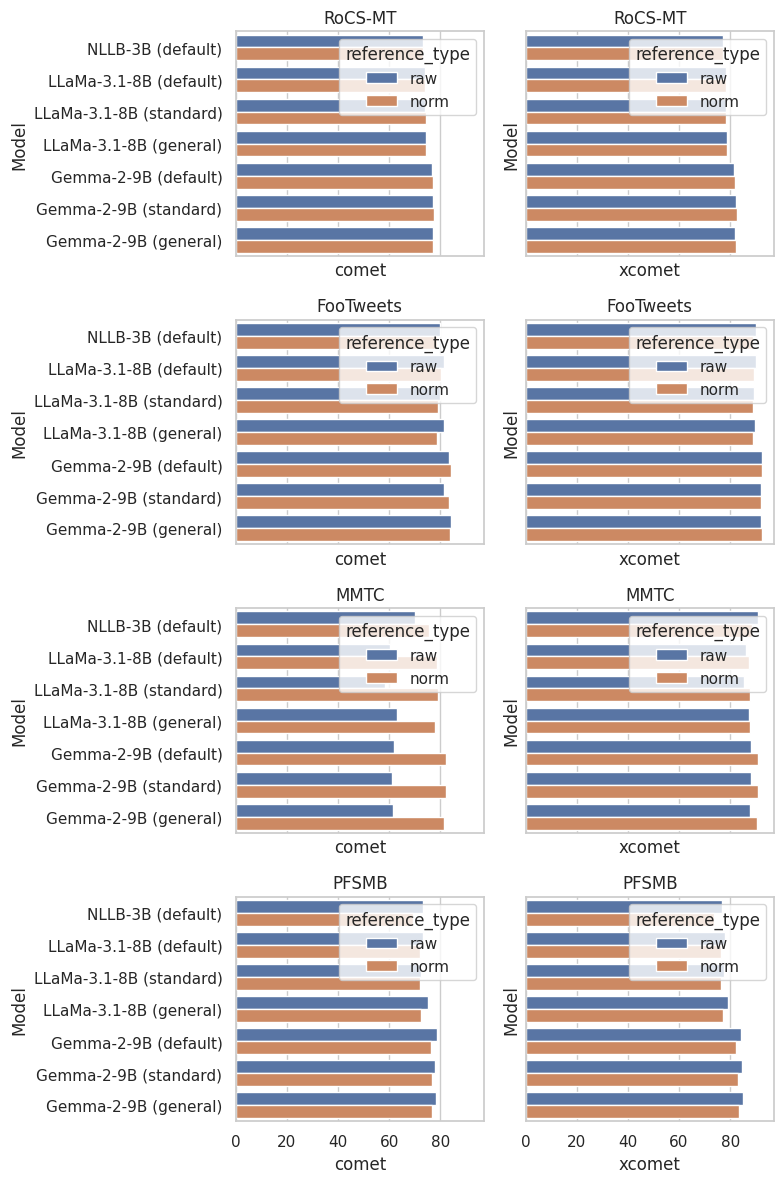

In [294]:
metrics = ["comet", "xcomet"]
plot_scores(all_data, metrics)

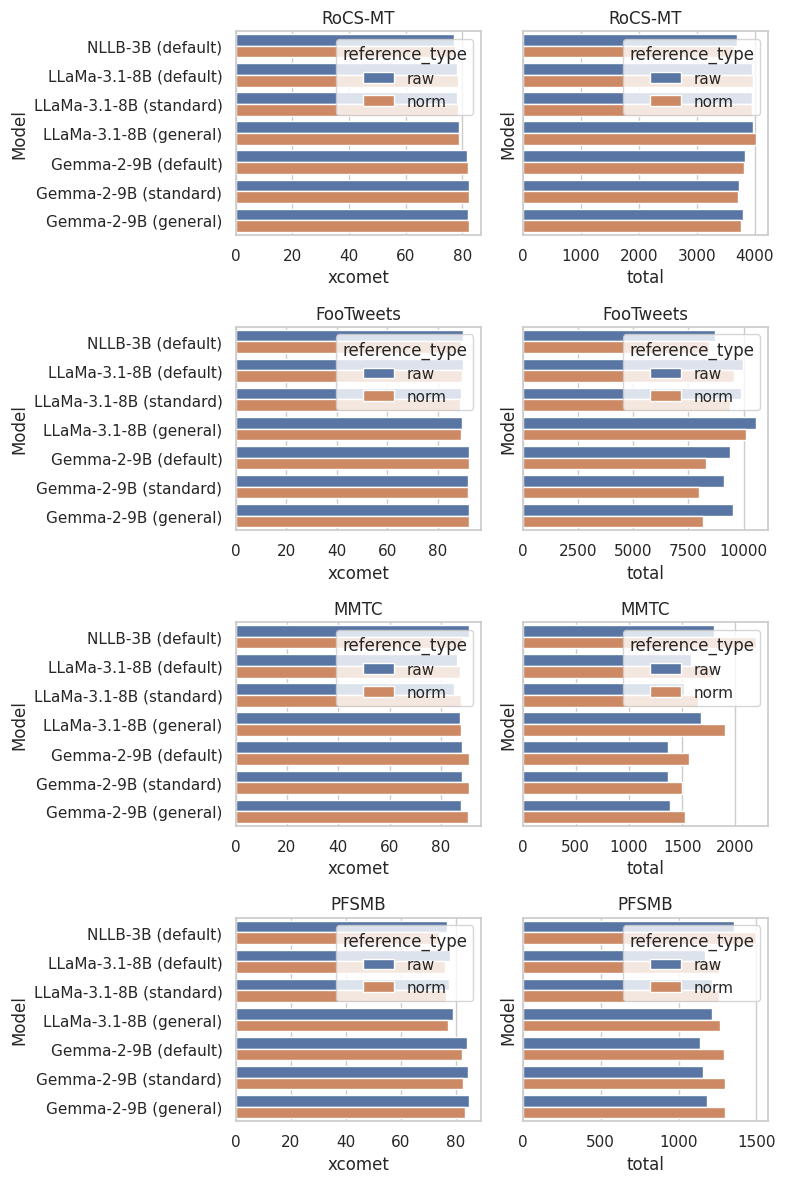

In [302]:
metrics = ["xcomet", "total"]
plot_scores(all_data, metrics, sharex=False)

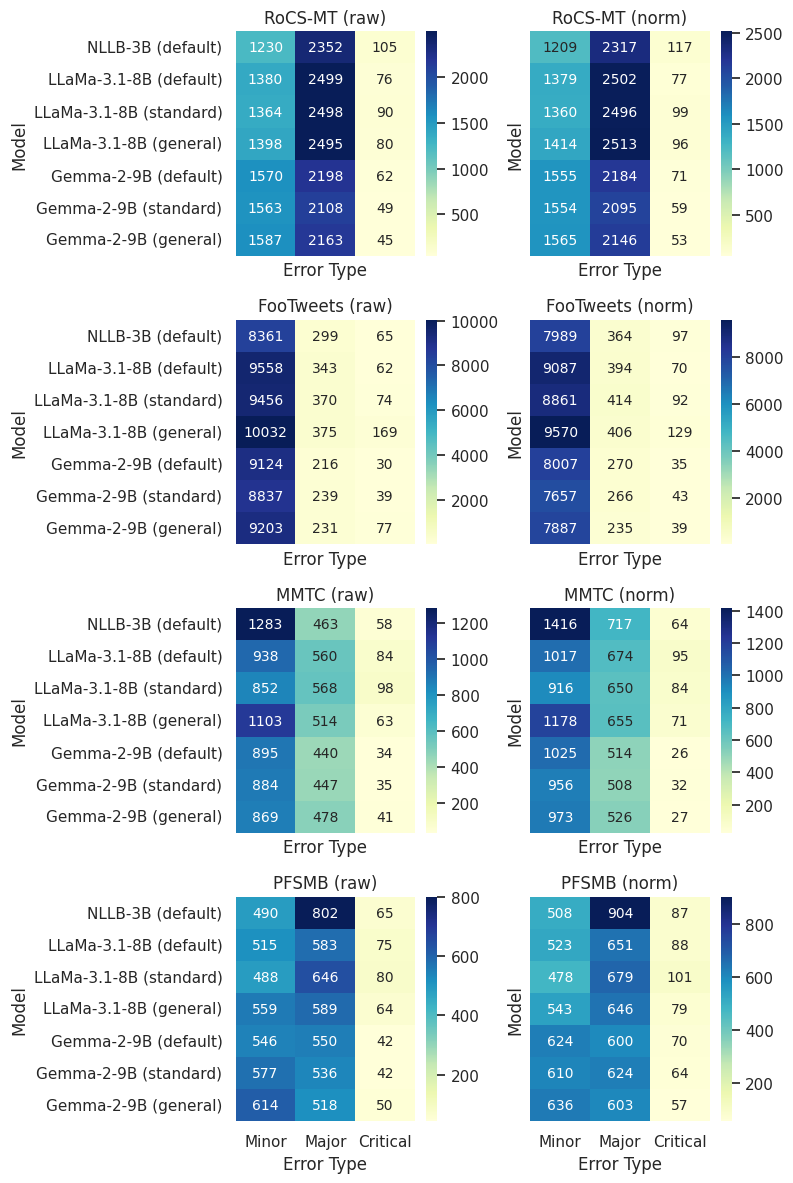

In [300]:
def plot_error_types(all_data):
    reference_types = all_data["reference_type"].unique()
    corpora = all_data["corpus"].unique()
    fig, axs = plt.subplots(len(corpora), len(reference_types), figsize=(4*len(reference_types), 3*len(corpora)), sharey=True, sharex=True)
    for i, corpus in enumerate(corpora):
        for j, ref in enumerate(reference_types):
            data = all_data[(all_data["corpus"] == corpus) & (all_data["reference_type"] == ref)]
            data = data[["model_name", "minor", "major", "critical"]]
            sns.heatmap(data.set_index("model_name"), annot=True, fmt=".0f", cmap="YlGnBu", ax=axs[i,j]) #, vmin=0, vmax=100)
            axs[i,j].set_title(f"{corpus} ({ref})")
            axs[i,j].set_ylabel("Model")
            axs[i,j].set_xlabel("Error Type")
            axs[i,j].set_xticklabels(["Minor", "Major", "Critical"])
            axs[i,j].set_yticklabels(data["model_name"].unique(), rotation=0)
            # reduce annotations font size
            for t in axs[i,j].texts:
                t.set_fontsize(10)
    plt.tight_layout()
    plt.show()

plot_error_types(all_data)

# Analyzing error types

In [303]:
import json

In [357]:
src_file = "/home/lnishimw/scratch/datasets/pfsmb/test.fr"
ref_file = "/home/lnishimw/scratch/datasets/pfsmb/test.en"
ref_file_norm = "/home/lnishimw/scratch/datasets/pfsmb/gpt.test.en"

def read_file(file):
    with open(file, "r") as f:
        #get lines without newline character
        return [line.strip() for line in f.readlines()]

src = read_file(src_file)
ref = read_file(ref_file)
ref_norm = read_file(ref_file_norm)


In [365]:
model = "google/gemma-2-9b-it"
guideline = "general."
sys_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/pfsmb/test.fr.{guideline}out"
error_file = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/pfsmb/test.fr.{guideline}out.errors.json"
error_file_norm = f"/home/lnishimw/scratch/experiments/evaluation-challenges/experiment_049/outputs/{model}/pfsmb-gpt/test.fr.{guideline}out.errors.json"

with open(error_file, "r") as f:
    errors = json.load(f)

with open(error_file_norm, "r") as f:
    errors_norm = json.load(f)

sys = read_file(sys_file)

In [366]:
critical_errors = get_errors(errors, "critical")
critical_errors_norm = get_errors(errors_norm, "critical")

major_errors = get_errors(errors, "major")
major_errors_norm = get_errors(errors_norm, "major")

minor_errors = get_errors(errors, "minor")
minor_errors_norm = get_errors(errors_norm, "minor")

In [367]:
all_errors = critical_errors.union(major_errors).union(minor_errors)
all_errors_norm = critical_errors_norm.union(major_errors_norm).union(minor_errors_norm)

In [368]:
no_errors = get_correct(errors)
no_errors_norm = get_correct(errors_norm)

In [369]:
print("raw", "gpt")
print(len(critical_errors), len(critical_errors_norm))
print(len(major_errors), len(major_errors_norm))
print(len(minor_errors), len(minor_errors_norm))
print(len(all_errors), len(all_errors_norm))
print(len(no_errors), len(no_errors_norm))


raw gpt
20 31
270 298
341 362
563 608
214 169


In [370]:
# get intersection of critical errors
intersection = critical_errors.intersection(all_errors)
print(len(intersection))

19


In [372]:
for i in critical_errors:
    print("Line", (i+1))
    print("SRC:", src[i])
    print("SYS:", sys[i])
    print("REF (raw):", ref[i])
    print("ERRORS (raw):", errors[i])
    print("REF (gpt):", ref_norm[i])
    print("ERRORS (gpt):", errors_norm[i])
    print()

Line 130
SRC: a toi Mathieu, jeune artiste en herbe extra-ordinaire, merci d'être là pour TOUT ce que tu nous offres, sourire, fraicheur, talent, folie, sincérité, originalité, une bonne dose d'oxygène... je te soutiens, et même si tu ne vas pas jusqu'au bout, c'est pareil, tu as tout gagné et tes futurs albums je les achèterai, et tes futures scènes j'y serai... et meme s'il y a eu quelques rouges, sans importance, même les plus grands artistes de la planète ne plaisent pas à tout le monde ! Reste toi, ne change rien, ne te déstabilise surtout pas. Et si récemment, "on" t'as dit que tu n'y mettais pas ton coeur... euhhhhh... jusque là, tu nous as bien prouvé que tu en avais un, la preuve flagrante dans Y'a quelqu'un qui m'a dit (un joyau et j'ai fondu en larmes). bonne chance Mathieu et quoi qu'il arrive : you are exceptionnel !!!!!!! bisoussssssssssssssssssssssssssssssssssssssssss
SYS: To Mathieu, young extraordinary budding artist, thank you for being there for EVERYTHING you offer 